<a href="https://colab.research.google.com/github/emilyalway1/BohorquezLab/blob/main/IntelliCage_SemaCohort2_PrePostAnalysis_EA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
from scipy.signal import savgol_filter
from datetime import datetime,timedelta
from statistics import mean
import colorsys
# Read the text file into a DataFrame called "visits"
# path: parent dir for txt files

path = ##REPLACE WITH THE FILE PATH FOR THE FOLDER THAT THE Visits.txt and Nosepokes.txt FILES ARE IN FOR THE PRE TIMEPOINT

file_path1 = path + "Visits.txt"
file_path2 = path + "Nosepokes.txt"
#change times in visits to relative data/time to first entry
visits_pre = pd.read_table(file_path1, header=0)
visits_pre['Session'] = ['Pre'] * len(visits_pre)

def reldatetime(df):
  df['Start'] = pd.to_datetime(df['Start'], format = '%Y-%m-%d %H:%M:%S.%f')
  df['End'] = pd.to_datetime(df['End'], format = '%Y-%m-%d %H:%M:%S.%f')
  if 'LickStartTime' in df.columns:
      df['LickStartTime'] = pd.to_datetime(df['LickStartTime'], format = '%Y-%m-%d %H:%M:%S.%f')
      df['LickStartTime'] = df['LickStartTime'] - df['Start'][0]
  df['End'] = df['End'] - df['Start'][0]
  df['Start'] = df['Start'] - df['Start'][0]
  return df

visits_pre = reldatetime(visits_pre)

nosepokes_pre = pd.read_table(file_path2, header=0)
nosepokes_pre['Session'] = ['Pre'] * len(nosepokes_pre)
nosepokes_pre = reldatetime(nosepokes_pre)

path = ##REPLACE WITH THE FILE PATH FOR THE FOLDER THAT THE Visits.txt and Nosepokes.txt FILES ARE IN FOR THE POST TIMEPOINT

file_path1 = path + "Visits.txt"
file_path2 = path + "Nosepokes.txt"
visits_post = pd.read_table(file_path1, header=0)
visits_post['Session'] = ['Post'] * len(visits_post)
visits_post = reldatetime(visits_post)
visits_post['VisitID'] = visits_post['VisitID'] + visits_pre['VisitID'].max() + 1


nosepokes_post = pd.read_table(file_path2, header=0)
nosepokes_post['Session'] = ['Post'] * len(nosepokes_post)
nosepokes_post = reldatetime(nosepokes_post)
nosepokes_post['VisitID'] = nosepokes_post['VisitID'] + visits_pre['VisitID'].max() + 1


# Get unique values in the "AnimalTag" column
animalTags = pd.DataFrame(columns = ['AnimalTag', 'Diet'])
animalTags['AnimalTag'] = visits_pre["AnimalTag"].unique()
animalTags['Diet'] = ['Chow'] * len(animalTags)

animalTags_post = pd.DataFrame(columns = ['AnimalTag', 'Diet'])
animalTags_post['AnimalTag'] = visits_post["AnimalTag"].unique()
animalTags_post['Diet'] = ['HFD'] * len(animalTags_post)

visits = pd.concat([visits_pre, visits_post]).reset_index()
nosepokes = pd.concat([nosepokes_pre, nosepokes_post]).reset_index()
animalTagsdf = pd.concat([animalTags, animalTags_post], axis = 0).reset_index()
animalTagsdf = animalTagsdf.drop(columns=['index'])
animalTags = animalTagsdf['AnimalTag']
visits = visits.sort_values(by='Start', ascending=True).reset_index()
visits = visits.drop(columns = ['level_0', 'index'])

nosepokes = nosepokes.sort_values(by='Start', ascending=True).reset_index()
nosepokes = nosepokes.drop(columns = ['level_0', 'index'])
#nosepokes
visits_pre


,VisitID,AnimalTag,Start,End,ModuleName,Cage,Corner,CornerCondition,PlaceError,AntennaNumber,AntennaDuration,PresenceNumber,PresenceDuration,VisitSolution,LickNumber,LickContactTime,LickDuration,Session
0,0,1825152,0 days 00:00:00,0 days 00:00:03.713000,Default,1,2,0,0,1,1.505163,1,6.313728,0,0,0.000,0.000000,Pre
1,1,1825152,0 days 00:00:17.552000,0 days 00:00:30.623000,Default,1,4,0,0,3,8.895447,1,13.311375,0,0,0.000,0.000000,Pre
2,3,1826218,0 days 00:01:07.033000,0 days 00:01:11.625000,Default,1,1,0,0,1,4.591752,1,4.815759,0,0,0.000,0.000000,Pre
3,4,1825393,0 days 00:01:22.696000,0 days 00:01:28.536000,Default,1,3,0,0,1,5.839685,1,5.215752,0,0,0.000,0.000000,Pre
4,2,1825442,0 days 00:00:44.719000,0 days 00:01:32.471000,Default,1,2,0,0,1,47.736565,1,48.184566,0,69,2.268,11.381853,Pre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6925,6925,1828002,3 days 23:55:57.862000,3 days 23:56:27.988000,Default,1,3,0,0,1,30.126125,1,31.198077,0,32,1.078,5.219993,Pre
6926,6926,1825393,3 days 23:57:28.870000,3 days 23:57:52.301000,Default,1,1,0,0,1,23.430375,1,23.270374,0,83,2.534,11.296126,Pre
6927,6928,1825393,3 days 23:58:46.974000,3 days 23:58:49.070000,Default,1,2,0,0,1,2.095873,1,1.711882,0,0,0.000,0.000000,Pre
6928,6927,1825230,3 days 23:57:58.653000,3 days 23:59:19.675000,Default,1,3,0,0,6,57.116821,1,81.118582,0,7,0.406,1.217945,Pre


In [ ]:
#cuts off visits of nospokes according to the entered day ("Start.days >= 3")

for row in range(visits.shape[0]):
  if visits.iloc[row].Start.days >= 3:
    print('index ' + str(row) + ' exceeds 3 days')
    maxIndex = row
    break
a = range(maxIndex,len(visits))
visits.drop(index = a, axis = 0, inplace = True )

for row in range(nosepokes.shape[0]):
  if nosepokes.iloc[row].Start.days >= 3:
    print('index ' + str(row) + ' exceeds 3 days')
    maxIndex = row
    break
a = range(maxIndex,len(nosepokes))
nosepokes.drop(index = a, axis = 0, inplace = True )
nosepokes


index 8432 exceeds 3 days
index 21561 exceeds 3 days


,VisitID,Start,End,Side,SideCondition,SideError,TimeError,ConditionError,LickNumber,LickContactTime,LickDuration,AirState,DoorState,LED1State,LED2State,LED3State,LickStartTime,Session
0,6930,-1 days +23:59:57.504000,-1 days +23:59:57.872000,4,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Post
1,6930,-1 days +23:59:57.904000,-1 days +23:59:58.128000,4,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Post
2,6930,-1 days +23:59:58.176000,-1 days +23:59:58.416000,4,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Post
3,6930,-1 days +23:59:58.528000,-1 days +23:59:59.312000,4,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Post
4,0,0 days 00:00:00,0 days 00:00:01.122000,3,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Pre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21556,10185,2 days 23:58:52.844000,2 days 23:59:00.028000,7,0,0,0,0,51,2.52,6.383956,0,0,0,0,0,2 days 23:58:53.500000,Post
21557,10185,2 days 23:59:09.628000,2 days 23:59:09.643000,8,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Post
21558,10185,2 days 23:59:11.979000,2 days 23:59:12.059000,7,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Post
21559,10185,2 days 23:59:12.075000,2 days 23:59:12.619000,7,0,0,0,0,0,0.00,0.000000,0,0,0,0,0,NaT,Post


In [ ]:
semaTags = [3790012, 3789075, 3787232, 3785531, 3785755, 3785719, 3788312, 3788227] #sema animal tags
vehicleTags = [3786187, 3785996, 3787149, 3789738, 3785753, 3785403, 3789115, 3787362] #sema animal tags
animalTags = semaTags + vehicleTags
cutTags = [] #No mice excluded from this cohort

#assigns treatment condition and removes animals that are missing from one file
visits.loc[visits['AnimalTag'].isin(semaTags), 'Treatment'] = "Sema"
visits.loc[visits['AnimalTag'].isin(vehicleTags), 'Treatment'] = "Vehicle"
visits = visits.drop(visits[visits['AnimalTag'].isin(cutTags)].index)

#nosepokes.loc[nosepokes['AnimalTag'].isin(semaTags), 'Treatment'] = "Sema"
#nosepokes.loc[nosepokes['AnimalTag'].isin(vehicleTags), 'Treatment'] = "Vehicle"
#nosepokes = nosepokes(visits[visits['AnimalTag'].isin(cutTags)].index)


In [ ]:
bottleNames = ["Bottle 1", "Bottle 2", "Bottle 3", "Bottle 4", "Bottle 5", "Bottle 6", "Bottle 7", "Bottle 8"]
bottleNames = ["Water", "Galactose", "Sucrose", "Sucralose", "Glucose", "Fructose", "Creamer", "Amino acids"]

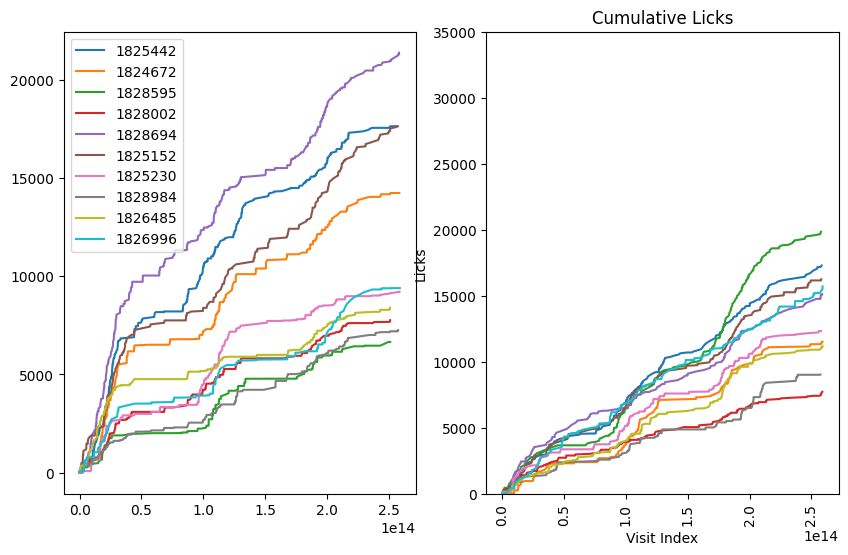

In [ ]:
fig, (ax1, ax2) = plt.subplots(figsize=(10, 6), ncols = 2)
for tag in animalTags:
  oneAnimalVisitsAll = visits[visits["AnimalTag"]==tag]
  oneAnimalVisits = oneAnimalVisitsAll
  dt_obj=pd.Series(dtype=float)
  #for timepoint in range(oneAnimalVisitsAll.shape[0]):
    #currentTimepoint = oneAnimalVisitsAll.iloc[timepoint].Start
    #currentTimepoint = datetime.strptime(stringDate,'%Y-%m-%d %H:%M:%S.%f')
  dt_obj = oneAnimalVisitsAll[oneAnimalVisitsAll['Session'] == 'Pre']["Start"]
  dt_obj2 = oneAnimalVisitsAll[oneAnimalVisitsAll['Session'] == 'Post']["Start"]
  ax1.plot(dt_obj,oneAnimalVisitsAll[oneAnimalVisitsAll['Session'] == 'Pre']["LickNumber"].cumsum(), label=tag)
  ax2.plot(dt_obj2,oneAnimalVisitsAll[oneAnimalVisitsAll['Session'] == 'Post']["LickNumber"].cumsum(),label=tag)

  plt.xlabel("Visit Index")
  plt.ylabel("Licks")
  plt.title("Cumulative Licks")
  ax1.legend()
  del dt_obj
  del dt_obj2

plt.xticks(rotation=90)
plt.ylim(0, 35000)
plt.show()
#fig.savefig(path + 'Cumulative licks per mouse.svg', format='svg')

/tmp/ipykernel_187/705441242.py:6: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.catplot(x = "Surgery", y = 'LickNumber', data = numLicks, hue = 'Session', palette = ['lightgray', 'darkgray', 'lightpink', 'hotpink'], kind = 'bar', order = od)
/tmp/ipykernel_187/705441242.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(x = "Surgery", y = 'LickNumber', data = numLicks, hue = 'Session', color = 'black', dodge = True)


<Axes: xlabel='Surgery', ylabel='LickNumber'>

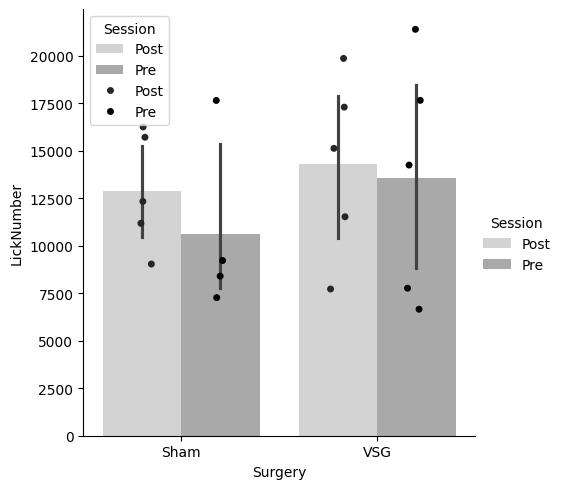

In [ ]:
import seaborn as sns
colors = ['lightgray', 'darkgray', 'lightpink', 'hotpink']
od = ['Vehicle', 'Sema']
numLicks = visits.groupby(['AnimalTag', 'Session', 'Treatment'])['LickNumber'].sum()
numLicks = pd.DataFrame(numLicks)
sns.catplot(x = "Treatment", y = 'LickNumber', data = numLicks, hue = 'Session', palette = ['lightgray', 'darkgray', 'lightpink', 'hotpink'], kind = 'bar', order = od)
sns.stripplot(x = "Treatment", y = 'LickNumber', data = numLicks, hue = 'Session', color = 'black', dodge = True)

In [ ]:
for nosepoke in range(len(nosepokes)): #Go through each element nosepoke
  mask = visits["VisitID"] == nosepokes.iloc[nosepoke,0] #In visits.txt find visits corresponding to nosepokes
  if (mask.sum() != 0):
    nosepokes.iloc[nosepoke,4] = visits[mask]["AnimalTag"] #Add the mousetag of visit to the nosepoke dataframe
  #print(visits[mask]["AnimalTag"])
nosepokes = nosepokes.rename(columns={'SideCondition': 'AnimalTag'}) #Now nosepokes has corresponding mouse tags

In [ ]:
d = {'Tag': [], 'Session': [], 'Treatment' : [], 'AllLicks': [], 'LicksBottle1': [],'LicksBottle2': [],'LicksBottle3': [],'LicksBottle4': [],
     'LicksBottle5': [],'LicksBottle6': [],'LicksBottle7': [],'LicksBottle8': []}

lickSummary_presema = pd.DataFrame(data=d)
lickSummary_postsema = pd.DataFrame(data=d)
for tag in semaTags:
  sumOfLicksPerMouse = nosepokes[nosepokes['AnimalTag']==tag].groupby('Session')["LickNumber"].sum() #Calculate total licks in session
  licksBottleArray=[]
  for bottle in range(8): #Jump through each bottle
    licksBottle1WholeSession= nosepokes[(nosepokes['AnimalTag']==tag) & (nosepokes['Side']==bottle+1)].groupby("Session")["LickNumber"].sum() #Calculate licks per bottle
    licksBottleArray.append(licksBottle1WholeSession) #Add licks of bottle to an array containing all 8
  licksBottleArray_pre = [x[1] for x in licksBottleArray]
  licksBottleArray_post = [x[0] for x in licksBottleArray]
  lickSummary_presema.loc[len(lickSummary_presema.index)] = [tag] + ['Pre'] + ['Sema'] + [sumOfLicksPerMouse[1]] +licksBottleArray_pre
  lickSummary_postsema.loc[len(lickSummary_postsema.index)] = [tag] + ['Post'] +['Sema'] + [sumOfLicksPerMouse[0]] +licksBottleArray_post   #concatenate the Tag, the Total Licks and 8 bottle values
  del licksBottleArray_pre
  del licksBottleArray_post

lickSummary_prevehicle = pd.DataFrame(data=d)
lickSummary_postvehicle = pd.DataFrame(data=d)
for tag in vehicleTags:
  sumOfLicksPerMouse = nosepokes[nosepokes['AnimalTag']==tag].groupby('Session')["LickNumber"].sum() #Calculate total licks in session
  licksBottleArray=[]
  for bottle in range(8): #Jump through each bottle
    licksBottle1WholeSession= nosepokes[(nosepokes['AnimalTag']==tag) & (nosepokes['Side']==bottle+1)].groupby("Session")["LickNumber"].sum() #Calculate licks per bottle
    licksBottleArray.append(licksBottle1WholeSession ) #Add licks of bottle to an array containing all 8
  licksBottleArray_pre = [x[1] for x in licksBottleArray]
  licksBottleArray_post = [x[0] for x in licksBottleArray]
  lickSummary_prevehicle.loc[len(lickSummary_prevehicle.index)] = [tag] + ['Pre'] + ['Vehicle'] + [sumOfLicksPerMouse[1]] +licksBottleArray_pre
  lickSummary_postvehicle.loc[len(lickSummary_postvehicle.index)] = [tag] + ['Post'] + ['Vehicle'] + [sumOfLicksPerMouse[0]] +licksBottleArray_post   #concatenate the Tag, the Total Licks and 8 bottle values
  del licksBottleArray_pre
  del licksBottleArray_post

lickSummary_vehicle = pd.concat([lickSummary_prevehicle, lickSummary_postvehicle], axis = 0).reset_index()
lickSummary_sema = pd.concat([lickSummary_presema, lickSummary_postsema], axis = 0).reset_index()
lickSummary_sema.drop(columns = 'index', inplace = True)
lickSummary_vehicle.drop(columns = 'index', inplace = True)

/tmp/ipykernel_187/2506301361.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  licksBottleArray_pre = [x[1] for x in licksBottleArray]
/tmp/ipykernel_187/2506301361.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  licksBottleArray_post = [x[0] for x in licksBottleArray]
/tmp/ipykernel_187/2506301361.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lickSummary_prevsg.loc[len(lickSummary_prevsg.index)] = [tag] + ['Pre'] + 

In [ ]:
lickSummary_prevehicle = pd.DataFrame(data = d)
lickSummary_postvehicle = pd.DataFrame(data = d)
for tag in vehicleTags:
  sumOfLicksPerMouse = nosepokes[nosepokes['AnimalTag']==tag].groupby('Session')["LickNumber"].sum() #Calculate total licks in session
  licksBottleArray=[]
  for bottle in range(8): #Jump through each bottle
    licksBottle1WholeSession= nosepokes[(nosepokes['AnimalTag']==tag) & (nosepokes['Side']==bottle+1)].groupby("Session")["LickNumber"].sum() #Calculate licks per bottle
    licksBottleArray.append(licksBottle1WholeSession ) #Add licks of bottle to an array containing all 8
  licksBottleArray_pre = [x[1] for x in licksBottleArray]
  licksBottleArray_post = [x[0] for x in licksBottleArray]
  lickSummary_prevehicle.loc[len(lickSummary_prevehicle.index)] = [tag] + ['Pre'] + ['Vehicle'] + [sumOfLicksPerMouse[1]] +licksBottleArray_pre
  lickSummary_postvehicle.loc[len(lickSummary_postvehicle.index)] = [tag] + ['Post'] + ['Vehicle'] + [sumOfLicksPerMouse[0]] +licksBottleArray_post   #concatenate the Tag, the Total Licks and 8 bottle values
  del licksBottleArray_pre
  del licksBottleArray_post
lickSummary_prevehicle

/tmp/ipykernel_187/1035580186.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  licksBottleArray_pre = [x[1] for x in licksBottleArray]
/tmp/ipykernel_187/1035580186.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  licksBottleArray_post = [x[0] for x in licksBottleArray]
/tmp/ipykernel_187/1035580186.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  lickSummary_presham.loc[len(lickSummary_presham.index)] = [tag] + ['Pre'] +

,Tag,Session,Surgery,AllLicks,LicksBottle1,LicksBottle2,LicksBottle3,LicksBottle4,LicksBottle5,LicksBottle6,LicksBottle7,LicksBottle8
0,1825152,Pre,Sham,17637,2178,178,3577,415,423,0,10866,0
1,1825230,Pre,Sham,9217,56,116,556,203,422,718,6660,486
2,1828984,Pre,Sham,7265,132,4,1260,95,1945,0,3823,6
3,1826485,Pre,Sham,8396,2121,63,153,302,178,151,5334,94
4,1826996,Pre,Sham,9397,0,3724,4,1111,0,94,4315,149


In [ ]:
# prompt: download lickSummary_postvehicle and lickSummary_prevehicle

lickSummary_postvehicle.to_csv('lickSummary_postvehicle-malecohort2.csv', index=False)
lickSummary_prevehicle.to_csv('lickSummary_prevehicle-malecohort2.csv', index=False)

lickSummary_postsema.to_csv('lickSummary_postsema-malecohort2.csv', index=False)
lickSummary_presema.to_csv('lickSummary_presema-malecohort2.csv', index=False)

from google.colab import files
files.download('lickSummary_postvehicle-malecohort2.csv')
files.download('lickSummary_prevehicle-malecohort2.csv')

files.download('lickSummary_postsema-malecohort2.csv')
files.download('lickSummary_presema-malecohort2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>